# Experiment #1: Trend-Following + Mean Reversion

In this notebook, we'll be testing out using two main trading rules provided by Rob Carver's *pysystemtrade* -- the exponentially weighted moving average crossover (EWMAC) trend following strategy and the mean reversion wings (MR Wings) strategy. These two strategies serve as good counterbalances to each other. The first is a pure trend-following strategy that attempts to pick up on momentum effects in markets, while the second is a mean-reversion strategy that fades extra-ordinary moves in markets away from their recent mean levels. 

This notebook is mostly focused on learning how to use pysystemtrade to build and aggregate more complex trading systems than the simplistic one developed in the [introduction.ipynb](introduction.ipynb) notebook we started with.


## Step 1: Import Data and Rule Prototypes

In [1]:
# get our data
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
data = csvFuturesSimData()

# get our default rules: ewmac and mr wings
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac 
from systems.provided.rules.mr_wings import mr_wings as mr_wings



Configuring sim logging


## Step 2: Create Trading Rules

In [2]:
# create TradingRules for each flavor of two rules
from systems.trading_rules import TradingRule

ewmac_64 = TradingRule(dict(
    function=ewmac,
    other_args=dict(Lfast=64, Lslow=256)
))

# mr_wings needs both price AND volatility
# price comes from data.daily_prices, vol comes from rawdata.daily_returns_volatility
mr_wings_4 = TradingRule(dict(
    function=mr_wings,
    data=["data.daily_prices", "rawdata.daily_returns_volatility"],
    other_args=dict(Lfast=4)
))

print("EWMAC_64 rule:")
print(ewmac_64)
print("\nMR_WINGS_4 rule:")
print(mr_wings_4)

EWMAC_64 rule:
TradingRule; function: <function ewmac_forecast_with_defaults at 0x132c4cc20>, data: data.daily_prices (args: {}) and other_args: Lfast, Lslow

MR_WINGS_4 rule:
TradingRule; function: <function mr_wings at 0x1332ca200>, data: data.daily_prices (args: {}), rawdata.daily_returns_volatility (args: {}) and other_args: Lfast


## Step 3: Use Config object to configure our system

In this step, we'll add our trading rules, instruments, and basic scaling/capping for our rule forecasts.

In [3]:
# instantiate a config object
from sysdata.config.configdata import Config 

my_config = Config()

# add instruments
my_config.instruments=['SP500', 'NASDAQ', 'US10']

# Set backtest start date to equalize data history across instruments
# NASDAQ data starts 1999-12-14, so we'll start from 2000-01-01
my_config.start_date = "2000-01-01"

# ensure we estimate a forecast scalar
from systems.forecast_scale_cap import ForecastScaleCap

my_config.use_forecast_scale_estimates = True 

fsc = ForecastScaleCap()

# add trading rules
my_config.trading_rules = dict(ewmac_64=ewmac_64, mr_wings_4=mr_wings_4)

## Step 4: Create the System with All Required Stages

Now we'll instantiate all the system stages needed for a complete backtest. We need:
- RawData: to handle price/volatility data
- Rules: to generate forecasts from our trading rules
- ForecastScaleCap: to scale and cap forecasts
- ForecastCombine: to combine multiple forecasts with proper weights
- PositionSizing: to size positions based on volatility targeting
- Portfolio: to combine multiple instruments
- Account: to calculate P&L and performance

In [4]:
# import all required system stages
from systems.basesystem import System
from systems.rawdata import RawData
from systems.forecasting import Rules
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecast_combine import ForecastCombine
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from systems.accounts.accounts_stage import Account

# instantiate empty stages (they'll read from config)
raw_data = RawData()
rules = Rules()  # empty - will read trading_rules from my_config
forecast_scale_cap = ForecastScaleCap()
forecast_combine = ForecastCombine()
position_sizing = PositionSizing()
portfolio = Portfolios()
account = Account()

print("✓ All system stages instantiated successfully")

✓ All system stages instantiated successfully


## Step 5: Configure Forecast Scaling

Raw forecasts from trading rules need to be scaled to have a target standard deviation of ~10 and capped at ±20. We can either:
- Use estimated scalars (system calculates from historical data)
- Use fixed scalars

For a proper backtest, we'll use estimated scalars with pooling across instruments.

In [5]:
# configure forecast scaling to estimate scalars from data
my_config.use_forecast_scale_estimates = True

# Create a minimal system to test forecast scaling
test_system = System([rules, forecast_scale_cap, raw_data], data, my_config)

# NOW we can set the pool_instruments parameter (system populates the config defaults)
my_config.forecast_scalar_estimate["pool_instruments"] = False

# examine raw forecasts before scaling
print("Raw EWMAC_64 forecast for SP500 (last 5 days):")
print(test_system.rules.get_raw_forecast("SP500", "ewmac_64").tail(5))
print(f"\nRaw forecast std: {test_system.rules.get_raw_forecast('SP500', 'ewmac_64').std():.2f}")

print("\n" + "="*60)
print("Raw MR_WINGS_4 forecast for SP500 (last 5 days):")
print(test_system.rules.get_raw_forecast("SP500", "mr_wings_4").tail(5))
print(f"\nRaw forecast std: {test_system.rules.get_raw_forecast('SP500', 'mr_wings_4').std():.2f}")

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
Raw EWMAC_64 forecast for SP500 (last 5 days):
2025-11-04 09:53:13 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 09:53:13 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 09:53:13 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 09:53:13 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for ewmac_64
index
2024-03-22    2.486182
2024-03-25    2.515756
2024-03-26    2.556725
2024-03-27    2.571565
2024-03-28    2.597562
Freq: B, Name: price, dtype: float64

Raw forecast std: 2.08

Raw MR_WINGS_4 forecast for SP500 (last 5 days):
2025-11-04 09:53:13 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for mr_wi

### Note on Configuration

**Important**: Notice in the cell above that we set `pool_instruments` **after** creating the system. This is because the System initialization populates the config with default dictionaries. You must create the system first before you can access nested config parameters like `forecast_scalar_estimate["pool_instruments"]`.

This pattern applies to other estimation configs too (`forecast_weight_estimate`, `instrument_weight_estimate`, etc.).

In [6]:
# now view the scaled forecasts
print("\nScaled EWMAC_64 forecast for SP500 (last 5 days):")
print(test_system.forecastScaleCap.get_scaled_forecast("SP500", "ewmac_64").tail(5))
print(f"\nScaled forecast std: {test_system.forecastScaleCap.get_scaled_forecast('SP500', 'ewmac_64').std():.2f}")
print("\nForecast scalar for SP500/ewmac_64:")
print(test_system.forecastScaleCap.get_forecast_scalar('SP500', 'ewmac_64'))

print("\n" + "="*60)
print("\nScaled MR_WINGS_4 forecast for SP500 (last 5 days):")
print(test_system.forecastScaleCap.get_scaled_forecast("SP500", "mr_wings_4").tail(5))
print(f"\nScaled forecast std: {test_system.forecastScaleCap.get_scaled_forecast('SP500', 'mr_wings_4').std():.2f}")
print("\nForecast scalar for SP500/mr_wings_4:")
print(test_system.forecastScaleCap.get_forecast_scalar('SP500', 'mr_wings_4'))

# check capping at ±20
print("\n" + "="*60)
print("\nCapped forecast for SP500/ewmac_64 (last 5 days):")
print(test_system.forecastScaleCap.get_capped_forecast("SP500", "ewmac_64").tail(5))


Scaled EWMAC_64 forecast for SP500 (last 5 days):
2025-11-04 09:53:13 DEBUG base_system {'stage': 'forecastScaleCap'} Getting cross sectional forecasts for scalar calculation for ewmac_64 over SP500
index
2024-03-22    12.400151
2024-03-25    12.547151
2024-03-26    12.750926
2024-03-27    12.824362
2024-03-28    12.953403
Freq: B, dtype: float64

Scaled forecast std: 11.71

Forecast scalar for SP500/ewmac_64:
index
2000-01-03    8.001849
2000-01-04    8.001849
2000-01-05    8.001849
2000-01-06    8.001849
2000-01-07    8.001849
                ...   
2024-03-22    4.987629
2024-03-25    4.987428
2024-03-26    4.987210
2024-03-27    4.986987
2024-03-28    4.986754
Freq: B, Name: SP500, Length: 6324, dtype: float64


Scaled MR_WINGS_4 forecast for SP500 (last 5 days):
2025-11-04 09:53:13 DEBUG base_system {'stage': 'forecastScaleCap'} Getting cross sectional forecasts for scalar calculation for mr_wings_4 over SP500
index
2024-03-22   NaN
2024-03-25   NaN
2024-03-26   NaN
2024-03-27   

## Step 6: Configure Forecast Combining

Now we combine our two trading rules (EWMAC and MR_Wings) into a single forecast per instrument. This requires:
1. **Forecast weights**: How much to allocate to each rule (e.g., 50/50, 60/40, etc.)
2. **Forecast diversification multiplier (FDM)**: Boosts the combined forecast to account for diversification benefit when rules are uncorrelated

We can estimate both from historical data or use fixed values.

In [7]:
# configure forecast weight and FDM estimation
my_config.use_forecast_weight_estimates = True
my_config.forecast_weight_estimate = dict(method="shrinkage")

# rebuild system with forecast combining
test_system_2 = System([rules, forecast_scale_cap, forecast_combine, raw_data, position_sizing, account], data, my_config)

# examine the forecast weights
print("Forecast weights for SP500 (last 5 days):")
print(test_system_2.combForecast.get_forecast_weights("SP500").tail(5))

print("\n" + "="*60)
print("\nForecast diversification multiplier for SP500 (last 5 days):")
print(test_system_2.combForecast.get_forecast_diversification_multiplier("SP500").tail(5))

print("\n" + "="*60)
print("\nCombined forecast for SP500 (last 5 days):")
print(test_system_2.combForecast.get_combined_forecast("SP500").tail(5))

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
Forecast weights for SP500 (last 5 days):
2025-11-04 09:53:13 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 09:53:13 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 09:53:13 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 09:53:13 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating forecast weights for SP500
2025-11-04 09:53:13 INFO base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating raw forecast weights for SP500
2025-11-04 09:53:13 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'NASDAQ'} Calculating capped forecast for NASDAQ ewmac_64
2025-11-04 09:53:13 DEBUG base_system {'stage': 'rules', 'instrument_code': 'NASD

/Users/devvarma/trades/pysystemtrade/syscore/maths.py:74: RuntimeWarning: divide by zero encountered in scalar divide
  renormalise_multiplier = renormalise_sum_to / sum_of_values
/Users/devvarma/trades/pysystemtrade/syscore/maths.py:75: RuntimeWarning: invalid value encountered in multiply
  new_values = array_of_values * renormalise_multiplier


2025-11-04 09:53:14 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US10'} Only this set of rules ['ewmac_64', 'mr_wings_4'] is cheap enough to trade for US10
2025-11-04 09:53:14 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating pandl for instrument forecast for NASDAQ ewmac_64
2025-11-04 09:53:14 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'NASDAQ'} Calculating daily prices for NASDAQ
2025-11-04 09:53:14 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2025-11-04 09:53:14 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating pandl for instrument forecast for NASDAQ mr_wings_4
2025-11-04 09:53:14 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'NASDAQ'} Calculating daily prices for NASDAQ
2025-11-04 09:53:14 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument forecast for SP500 ewmac_64
2025-11-04 09:53:14 DEBUG base_system {'s

/Users/devvarma/trades/pysystemtrade/sysquant/optimisation/pre_processing.py:258: RuntimeWarning: Mean of empty slice
  return np.nanmean(list(all_turnovers.values()))


## Step 7: Configure Position Sizing with Volatility Targeting

Position sizing converts our combined forecasts (scaled -20 to +20) into actual positions. The system uses volatility targeting to ensure consistent risk across instruments and time. Key parameters:
- **percentage_vol_target**: Target annualized volatility (e.g., 25% means we want the portfolio to have ~25% annual vol)
- **notional_trading_capital**: Starting capital in base currency
- **base_currency**: Currency for capital (e.g., "USD", "GBP")

The system calculates position sizes so that each instrument contributes equally to risk at the subsystem level.

In [8]:
# configure position sizing parameters
my_config.percentage_vol_target = 15
my_config.notional_trading_capital = 1_000_000
my_config.base_currency = "USD"

# rebuild system with position sizing
test_system_3 = System([rules, forecast_scale_cap, forecast_combine, position_sizing, raw_data, account], data, my_config)

# examine position sizing calculations
print("Price volatility for SP500 (last 5 days):")
print(test_system_3.positionSize.get_price_volatility("SP500").tail(5))

print("\n" + "="*60)
print("\nInstrument value volatility for SP500 (last 5 days):")
print(test_system_3.positionSize.get_instrument_value_vol("SP500").tail(5))

print("\n" + "="*60)
print("\nSubsystem position for SP500 (last 5 days):")
print(test_system_3.positionSize.get_subsystem_position("SP500").tail(5))

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
Price volatility for SP500 (last 5 days):
2025-11-04 09:53:15 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 09:53:15 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 09:53:15 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 09:53:15 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SP500'} Calculating daily volatility for SP500
2025-11-04 09:53:15 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SP500'} Calculating daily prices for SP500
index
2024-03-22    0.601856
2024-03-25    0.594350
2024-03-26    0.586340
2024-03-27    0.580944
2024-03-28    0.571660
Freq: B, dtype: float64


Instrument value volatility for SP500 (last 5 days):
2025-11-04 09:53:15 DEBUG base_system {'sta

/Users/devvarma/trades/pysystemtrade/syscore/maths.py:74: RuntimeWarning: divide by zero encountered in scalar divide
  renormalise_multiplier = renormalise_sum_to / sum_of_values
/Users/devvarma/trades/pysystemtrade/syscore/maths.py:75: RuntimeWarning: invalid value encountered in multiply
  new_values = array_of_values * renormalise_multiplier


2025-11-04 09:53:16 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US10'} Only this set of rules ['ewmac_64', 'mr_wings_4'] is cheap enough to trade for US10
2025-11-04 09:53:16 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating pandl for instrument forecast for NASDAQ ewmac_64
2025-11-04 09:53:16 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'NASDAQ'} Calculating daily prices for NASDAQ
2025-11-04 09:53:16 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Getting vol target
2025-11-04 09:53:16 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating pandl for instrument forecast for NASDAQ mr_wings_4
2025-11-04 09:53:16 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'NASDAQ'} Calculating daily prices for NASDAQ
2025-11-04 09:53:17 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument forecast for SP500 ewmac_64
2025-11-04 09

/Users/devvarma/trades/pysystemtrade/sysquant/optimisation/pre_processing.py:258: RuntimeWarning: Mean of empty slice
  return np.nanmean(list(all_turnovers.values()))


### ● Learn by Doing

**Context:** Position sizing is how we convert abstract forecasts into real contract positions. A forecast of +10 means "take half your maximum position long". The system needs to know: (1) How much capital you're trading with, (2) How much volatility you want to target (risk tolerance), and (3) What currency your capital is in. These determine the actual position sizes.

**Your Task:** In the code cell above where it says `# TODO(human)`, add 3 lines to configure position sizing:
1. `my_config.percentage_vol_target = ?` - Annual volatility target (typical range: 10-30%)
2. `my_config.notional_trading_capital = ?` - Starting capital amount
3. `my_config.base_currency = "?"` - Currency code (e.g., "USD", "GBP")

**Guidance:** The vol target represents your risk tolerance - institutional CTAs often use 15-25%, retail might use 10-15%. For learning purposes, you could use 25% (moderately aggressive) with $500,000 capital in "USD". Lower vol targets = smaller positions = less P&L volatility. The capital amount scales your positions linearly but doesn't affect Sharpe ratios.

## Step 8: Configure Portfolio with Instrument Weights and Diversification

At the portfolio level, we combine positions across multiple instruments (SP500, NASDAQ, US10). Similar to forecast combining, we need:
1. **Instrument weights**: How much capital to allocate to each instrument
2. **Instrument diversification multiplier (IDM)**: Boosts positions to account for diversification across instruments

We can estimate these from historical returns or use fixed values.

In [9]:
# configure portfolio-level instrument weights and IDM
my_config.use_instrument_weight_estimates = True
my_config.instrument_weight_estimate = dict(method='shrinkage', date_method='in_sample')
my_config.use_instrument_div_mult_estimates = True

# build the complete system with all stages
my_system = System(
    [account, portfolio, position_sizing, forecast_combine, forecast_scale_cap, rules, raw_data], 
    data, 
    my_config
)

# examine instrument weights
print("Instrument weights (last 5 days):")
print(my_system.portfolio.get_instrument_weights().tail(5))

print("\n" + "="*60)
print("\nInstrument diversification multiplier (last 5 days):")
print(my_system.portfolio.get_instrument_diversification_multiplier().tail(5))

print("\n" + "="*60)
print("\nNotional position for SP500 (last 5 days):")
print(my_system.portfolio.get_notional_position("SP500").tail(5))

print("\n" + "="*60)
print("\nNotional position for US10 (last 5 days):")
print(my_system.portfolio.get_notional_position("US10").tail(5))

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
Instrument weights (last 5 days):
2025-11-04 09:53:18 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 09:53:18 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 09:53:18 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 09:53:18 INFO base_system {'stage': 'portfolio'} Calculating instrument weights
2025-11-04 09:53:18 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 09:53:18 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 09:53:18 DEBUG base_system Following instruments are marked as 'bad_markets':  ['BAD_EXAMPLE']
2025-11-04 09:53:18 DEBUG base_system Following instruments have

/Users/devvarma/trades/pysystemtrade/syscore/maths.py:74: RuntimeWarning: divide by zero encountered in scalar divide
  renormalise_multiplier = renormalise_sum_to / sum_of_values
/Users/devvarma/trades/pysystemtrade/syscore/maths.py:75: RuntimeWarning: invalid value encountered in multiply
  new_values = array_of_values * renormalise_multiplier


2025-11-04 09:53:19 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'NASDAQ'} Getting vol target
2025-11-04 09:53:19 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating pandl for instrument forecast for NASDAQ mr_wings_4
2025-11-04 09:53:19 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'NASDAQ'} Calculating daily prices for NASDAQ
2025-11-04 09:53:19 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument forecast for SP500 ewmac_64
2025-11-04 09:53:19 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SP500'} Calculating daily prices for SP500
2025-11-04 09:53:19 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument forecast for SP500 mr_wings_4
2025-11-04 09:53:19 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SP500'} Calculating daily prices for SP500
2025-11-04 09:53:20 DEBUG base_system {'stage': 'accounts', 'instru

/Users/devvarma/trades/pysystemtrade/sysquant/optimisation/pre_processing.py:258: RuntimeWarning: Mean of empty slice
  return np.nanmean(list(all_turnovers.values()))
/Users/devvarma/trades/pysystemtrade/sysquant/optimisation/pre_processing.py:258: RuntimeWarning: Mean of empty slice
  return np.nanmean(list(all_turnovers.values()))


 [================================================================================] 100.0% Optimising weights (0.0/0.0/0.0 secs left/elapsed/total)                 
2025-11-04 09:53:20 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Only this set of rules ['ewmac_64', 'mr_wings_4'] is cheap enough to trade for SP500
2025-11-04 09:53:20 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Using fixed FDM multiplier of 1.000 for SP500
2025-11-04 09:53:20 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} No mapping applied for SP500
2025-11-04 09:53:20 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'US10'} Calculating subsystem position for US10
2025-11-04 09:53:20 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'US10'} Calculating volatility scalar for US10
2025-11-04 09:53:20 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'US10'} Calculating instrument value vol for US10
2025-

/Users/devvarma/trades/pysystemtrade/sysquant/optimisation/pre_processing.py:258: RuntimeWarning: Mean of empty slice
  return np.nanmean(list(all_turnovers.values()))


2025-11-04 09:53:21 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for subsystem for instrument SP500
2025-11-04 09:53:21 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Calculating buffers for SP500
2025-11-04 09:53:21 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Calculating forecast method buffers for SP500
2025-11-04 09:53:21 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating buffered subsystem positions
2025-11-04 09:53:21 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SP500'} Calculating daily prices for SP500
2025-11-04 09:53:21 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'US10'} Calculating pandl for subsystem for instrument US10
2025-11-04 09:53:21 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'US10'} Calculating buffers for US10
2025-11-04 09:53:21 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'US10'

### ● Learn by Doing

**Context:** We need to allocate our capital across three instruments: SP500, NASDAQ (both US equity indices - likely highly correlated), and US10 (Treasury bonds - often negatively correlated with equities in risk-off periods). The instrument weights determine capital allocation, and the IDM accounts for diversification benefits. Since SP500 and NASDAQ are both US equities, they won't provide much diversification from each other.

**Your Task:** In the code cell above where it says `# TODO(human)`, configure the portfolio level. You need to add 3-4 lines:
1. `my_config.use_instrument_weight_estimates = True` - To estimate from data
2. `my_config.instrument_weight_estimate = dict(method="shrinkage", date_method="in_sample")` 
3. `my_config.use_instrument_div_mult_estimates = True` - To estimate IDM from data

**Guidance:** SP500 and NASDAQ are ~80-90% correlated, so combined they're almost like one asset. US10 provides real diversification. The shrinkage method will regularize the weights to avoid extreme allocations. For IDM, with high correlation between two equities, expect something around 1.2-1.5 rather than 2.0+. The `date_method="in_sample"` speeds up calculation for learning purposes.

## Step 9: Analyze Backtest Results and Performance

Now that we have a complete system configured, let's examine the backtest results. We'll look at:
- Portfolio P&L curve
- Performance statistics (Sharpe ratio, returns, drawdowns)
- Gross vs net returns (with trading costs)
- Per-instrument contributions

In [10]:
# get portfolio-level performance
portfolio_returns = my_system.accounts.portfolio()

# display key statistics
print("=" * 70)
print("PORTFOLIO PERFORMANCE STATISTICS (GROSS - before costs)")
print("=" * 70)
print(portfolio_returns.gross.percent.stats())

print("\n" + "=" * 70)
print("PORTFOLIO PERFORMANCE STATISTICS (NET - after costs)")
print("=" * 70)
print(portfolio_returns.net.percent.stats())

2025-11-04 09:53:22 INFO base_system {'stage': 'accounts', 'instrument_code': 'US10'} Calculating pandl for portfolio
2025-11-04 09:53:22 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating pandl for instrument for NASDAQ
2025-11-04 09:53:22 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'NASDAQ'} Calculating notional position for NASDAQ
2025-11-04 09:53:22 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'NASDAQ'} No risk overlay in config: won't apply risk scaling
2025-11-04 09:53:22 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'NASDAQ'} Calculating buffers for NASDAQ
2025-11-04 09:53:22 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'NASDAQ'} Calculating forecast method buffers for NASDAQ
2025-11-04 09:53:22 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating buffered positions
2025-11-04 09:53:22 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculati

### Understanding the Performance Statistics

Here's what each metric means:

**Basic Statistics:**
- **min/max**: Worst and best single day returns (%)
- **median/mean**: Center and average of daily returns
- **std**: Standard deviation of daily returns (volatility)
- **skew**: Shape of return distribution (negative = more left tail risk)

**Annualized Performance:**
- **ann_mean**: Annual return (mean × 256 trading days) - **This is your yearly return %**
- **ann_std**: Annual volatility (std × √256) - **Risk level**
- **sharpe**: Return/Risk ratio (ann_mean/ann_std) - **>0.5 is good, >1.0 is excellent**
- **sortino**: Like Sharpe but only penalizes downside volatility

**Drawdown Metrics (how bad are the losses):**
- **avg_drawdown**: Average peak-to-trough decline from highs
- **time_in_drawdown**: Fraction of time spent below previous peak (0.93 = 93% of time)
- **calmar**: Return/worst drawdown ratio
- **avg_return_to_drawdown**: How much you make relative to losses

**Win/Loss Analysis:**
- **avg_loss/avg_gain**: Average size of losing vs winning days
- **gaintolossratio**: avg_gain/avg_loss (>1 means winners bigger than losers)
- **profitfactor**: Total gains/total losses (>1 means profitable overall)
- **hitrate**: Fraction of profitable days (0.55 = 55% win rate)

**Statistical Significance:**
- **t_stat**: How confident we are returns aren't random
- **p_value**: Probability results are due to luck (<0.05 is statistically significant)

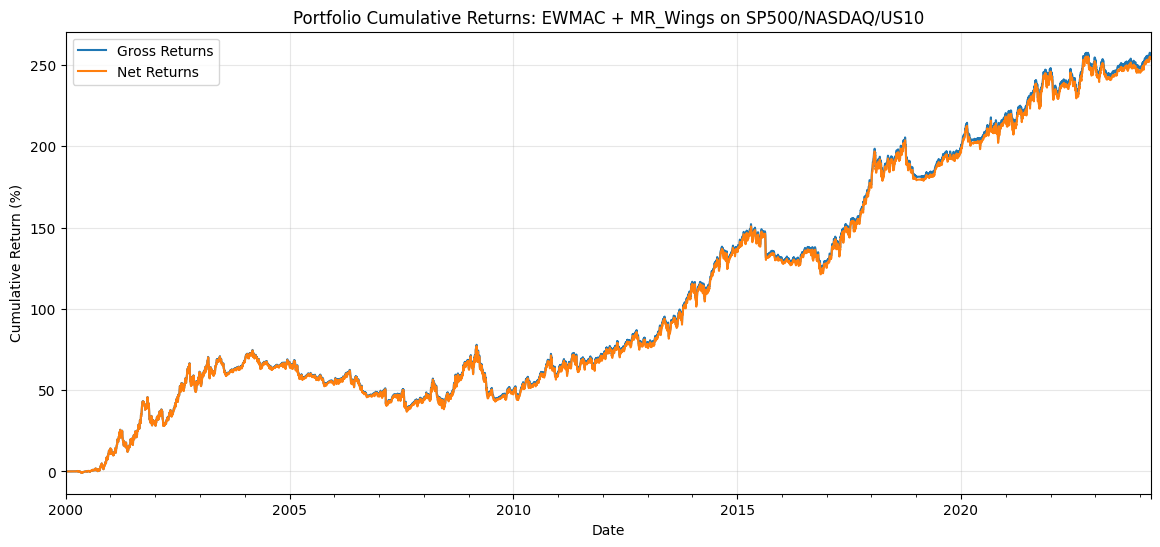

In [11]:
# plot the cumulative returns
import matplotlib.pyplot as plt

portfolio_returns.gross.percent.curve().plot(label='Gross Returns', figsize=(14, 6))
portfolio_returns.net.percent.curve().plot(label='Net Returns')
plt.title('Portfolio Cumulative Returns: EWMAC + MR_Wings on SP500/NASDAQ/US10')
plt.ylabel('Cumulative Return (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# examine per-instrument performance
print("=" * 70)
print("PER-INSTRUMENT PERFORMANCE")
print("=" * 70)

for instrument in my_config.instruments:
    print(f"\n{instrument}:")
    inst_returns = my_system.accounts.pandl_for_instrument(instrument)
    print(inst_returns.percent.stats())

PER-INSTRUMENT PERFORMANCE

SP500:
2025-11-04 09:53:23 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument for SP500
2025-11-04 09:53:23 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument for SP500
[[('min', '-6.011'), ('max', '2.356'), ('median', '0'), ('mean', '0.0134'), ('std', '0.4744'), ('skew', '-1.091'), ('ann_mean', '3.431'), ('ann_std', '7.591'), ('sharpe', '0.452'), ('sortino', '0.4967'), ('avg_drawdown', '-6.568'), ('time_in_drawdown', '0.933'), ('calmar', '0.1819'), ('avg_return_to_drawdown', '0.5224'), ('avg_loss', '-0.3413'), ('avg_gain', '0.3261'), ('gaintolossratio', '0.9554'), ('profitfactor', '1.097'), ('hitrate', '0.5344'), ('t_stat', '2.247'), ('p_value', '0.02469')], ('You can also plot / print:', ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

NASDAQ:
2025-11-04 09:53:23 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'NASDAQ'} Calculating pandl for